In [1]:
import sys
from pathlib import Path

# Add the project root to python path so we can import src
# Assumes notebook is in 'quant-portfolio/notebooks/'
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Enable auto-reloading so if you change data_manager.py, the notebook picks it up
%load_ext autoreload
%autoreload 2

print(f"Project Root: {project_root}")

Project Root: c:\Users\reymo\quant-portfolio


In [ ]:
from src.data.data_manager import DataManager

# 1. Initialize the DataManager
# We store data in a 'data/storage' folder at the project root
manager = DataManager(base_dir=project_root / "data" / "raw")

# 2. Choose a ticker
ticker = "NVDA"


# 3. Load from Disk (The Moment of Truth)
print("Loading data back from storage...")
df_loaded = manager.load_ticker(ticker)

# 4. Verification
print(f"\nLoaded {len(df_loaded)} rows.")
print(f"Head of data:\n{df_loaded.head(3)}")
print(f"\nTail of data:\n{df_loaded.tail(3)}")

Loading data back from storage...

Loaded 1006 rows.
Head of data:
Price          Close      High       Low      Open     Volume  year month
Date                                                                     
2020-01-02  5.971079  5.971079  5.891684  5.942208  237536000  2020     1
2020-01-03  5.875504  5.919309  5.826473  5.851362  205384000  2020     1
2020-01-06  5.900144  5.905371  5.756038  5.782171  262636000  2020     1

Tail of data:
Price           Close       High        Low       Open     Volume  year month
Date                                                                         
2023-12-27  49.389481  49.652335  49.057665  49.483430  233648000  2023    12
2023-12-28  49.494427  49.856225  49.384487  49.615362  246587000  2023    12
2023-12-29  49.494427  49.969165  48.723856  49.785265  389293000  2023    12


## 3. Mathematical Feature Engineering

### Why Log Returns?
We use **Log Returns** ($r_t$) instead of Simple Returns ($R_t$) for two main reasons:

1.  **Time Additivity:** Log returns can be summed over time to get the total return.
    $$r_{total} = \sum r_i$$
    (Simple returns require geometric multiplication, which is harder to model).
2.  **Statistical Properties:** Log returns are unbounded $(-\infty, \infty)$, whereas simple returns are bounded at -100%. This makes log returns closer to a Normal Distribution, simplifying future modeling.

**Formula:**
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [4]:
# CELL 3 : transforms raw prices into statstical returns and volatility
import numpy as np

# Create a working copy so we don't mess up the original loaded dataframe
df = df_loaded.copy()

# ---------------------------------------------------------
# 1. Determine which column to use
# ---------------------------------------------------------
# 'Adj Close' accounts for dividends/splits. Prefer it if available.
price_col = "Adj Close" if "Adj Close" in df.columns else "Close"
print(f"Using column: {price_col}")

# ---------------------------------------------------------
# 2. Calculate Log Returns
# ---------------------------------------------------------
# Formula: r_t = ln(P_t) - ln(P_{t-1})
df["log_ret"] = np.log(df[price_col] / df[price_col].shift(1))

# ---------------------------------------------------------
# 3. Calculate Rolling Volatility (21-day window)
# ---------------------------------------------------------
# We use a 21-day window (approx 1 trading month).
# We multiply by sqrt(252) to "annualize" the daily standard deviation.
df["volatility_21d"] = df["log_ret"].rolling(window=21).std() * np.sqrt(252)

# ---------------------------------------------------------
# 4. Cleanup
# ---------------------------------------------------------
# The first row of log return will be NaN (due to shift).
# The first 20 rows of volatility will be NaN (due to rolling window).
df.dropna(inplace=True)

print("Feature Engineering Complete.")
print(df[["log_ret", "volatility_21d"]].describe())

Using column: Close
Feature Engineering Complete.
Price     log_ret  volatility_21d
count  985.000000      985.000000
mean     0.002162        0.508061
std      0.034184        0.195459
min     -0.203979        0.197012
25%     -0.016103        0.360724
50%      0.003137        0.481816
75%      0.021850        0.619228
max      0.218088        1.393048


0.002161973896888606 0.03416626011842037


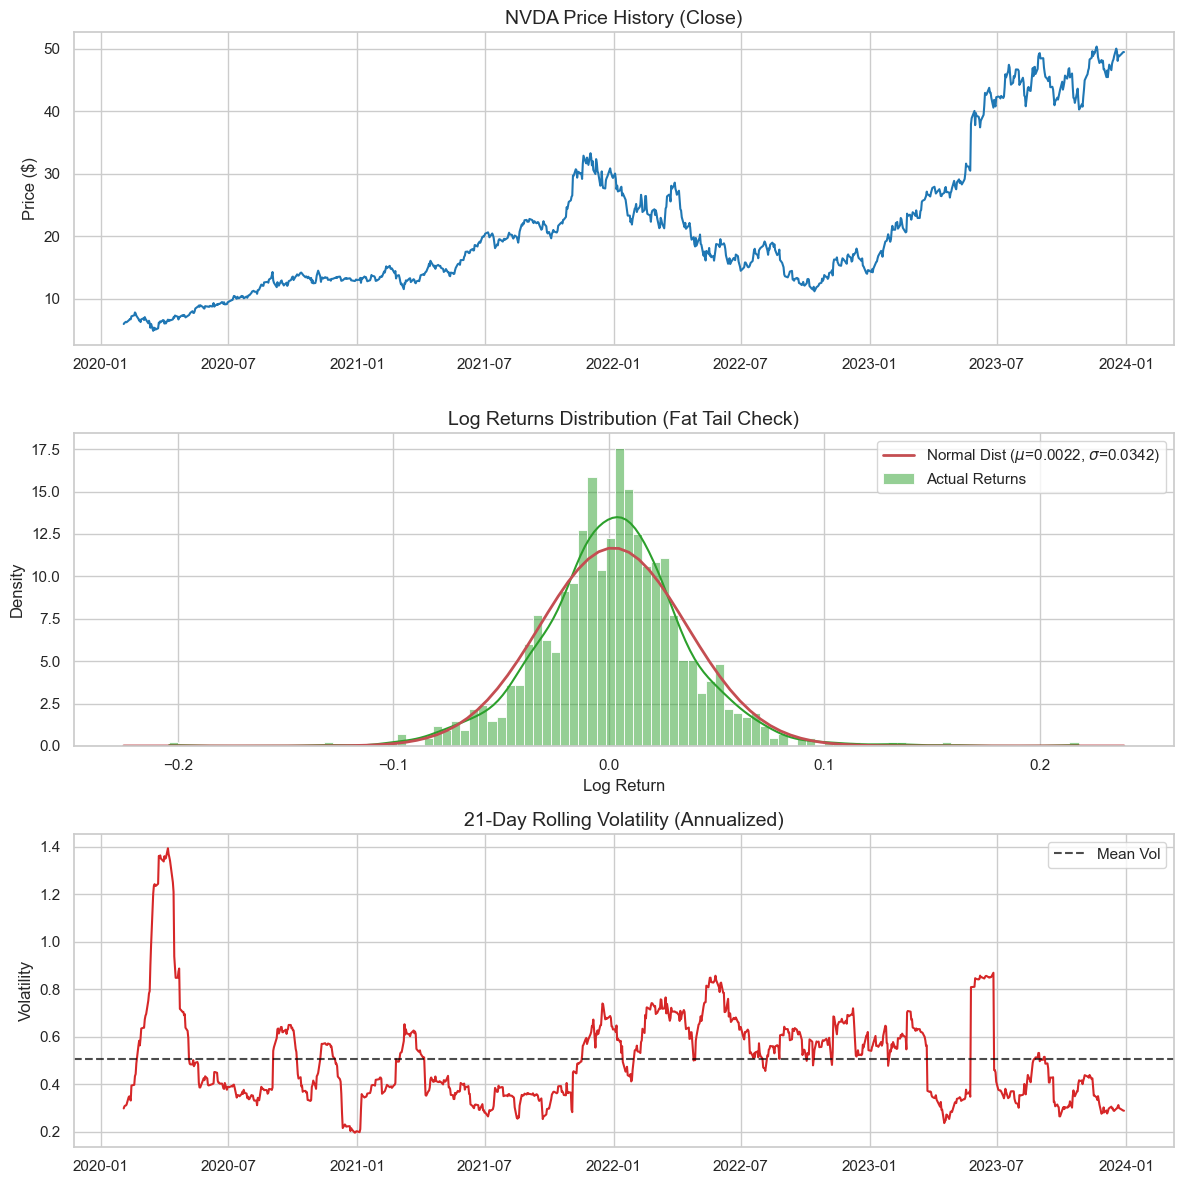

In [ ]:
# CELL 4 : generates 3 critical plots : Price history,
# distribution (fat tails) and volatility clustering

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Aesthetic settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [12, 12]  # Taller figure to stack 3 plots

# Create a figure with 3 subplots
fig, axes = plt.subplots(3, 1, sharex=False)

# ---------------------------------------------------------
# Plot 1: Price History
# ---------------------------------------------------------
axes[0].plot(df.index, df[price_col], color="#1f77b4", linewidth=1.5)
axes[0].set_title(f"{ticker} Price History ({price_col})", fontsize=14)
axes[0].set_ylabel("Price ($)")

# ---------------------------------------------------------
# Plot 2: Returns Distribution vs Normal Distribution
# ---------------------------------------------------------
# The Histogram of our actual data
sns.histplot(
    df["log_ret"],
    bins=100,
    kde=True,
    ax=axes[1],
    color="#2ca02c",
    stat="density",
    label="Actual Returns",
)

# The Theoretical Normal Distribution (Red Line)
mu, std = norm.fit(df["log_ret"])
xmin, xmax = axes[1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
axes[1].plot(
    x, p, "r", linewidth=2, label=rf"Normal Dist ($\mu$={mu:.4f}, $\sigma$={std:.4f})"
)

axes[1].legend()
axes[1].set_title("Log Returns Distribution (Fat Tail Check)", fontsize=14)
axes[1].set_xlabel("Log Return")

# ---------------------------------------------------------
# Plot 3: Volatility Regimes
# ---------------------------------------------------------
axes[2].plot(df.index, df["volatility_21d"], color="#d62728", linewidth=1.5)
axes[2].axhline(
    df["volatility_21d"].mean(),
    color="black",
    linestyle="--",
    alpha=0.7,
    label="Mean Vol",
)
axes[2].set_title("21-Day Rolling Volatility (Annualized)", fontsize=14)
axes[2].set_ylabel("Volatility")
axes[2].legend()

plt.tight_layout()
plt.show()

In [27]:
from statsmodels.tsa.stattools import adfuller


def test_stationarity(timeseries, name="Series"):
    print(f"--- ADF Test for {name} ---")
    result = adfuller(timeseries.dropna())
    adf_stat = result[0]
    p_value = result[1]

    print(f"ADF Statistic: {adf_stat:.4f}")
    print(f"p-value:       {p_value:.4e}")

    # Critical values
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"\t{key}: {value:.4f}")

    if p_value < 0.05:
        print(f"✅ Result: {name} is STATIONARY (Reject Null Hypothesis)")
    else:
        print(f"❌ Result: {name} is NON-STATIONARY (Fail to Reject H0)")
    print("")


# Test 1: Raw Prices (Expect Non-Stationary)
test_stationarity(df[price_col], "Raw Prices")

# Test 2: Log Returns (Expect Stationary)
test_stationarity(df["log_ret"], "Log Returns")

--- ADF Test for Raw Prices ---
ADF Statistic: 0.0467
p-value:       9.6223e-01
Critical Values:
	1%: -3.4370
	5%: -2.8645
	10%: -2.5683
❌ Result: Raw Prices is NON-STATIONARY (Fail to Reject H0)

--- ADF Test for Log Returns ---
ADF Statistic: -9.7091
p-value:       1.0230e-16
Critical Values:
	1%: -3.4371
	5%: -2.8645
	10%: -2.5683
✅ Result: Log Returns is STATIONARY (Reject Null Hypothesis)

